In [9]:
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import FastSAM
import time

# --- Configurations ---
dummy_point = [200, 700]  # Pixel to target [x, y]
image_path = 'sa_2.jpg'
json_path = 'sa_2.json'

print("1. Loading Image & GT Data...")
img = cv2.imread(image_path)
if img is None: raise ValueError(f"Could not load {image_path}")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
original_shape = img.shape[:2]

actual_mask = np.zeros(original_shape, dtype=np.uint8)
try:
    with open(json_path, 'r') as f:
        data = json.load(f)
        px, py = dummy_point
        min_area = float('inf')
        for ann in data.get('annotations', []):
            seg = ann['segmentation']
            if isinstance(seg, dict):
                h, w = seg['size']
                counts = seg['counts']
                if isinstance(counts, list):
                    mask_1d = np.zeros(h * w, dtype=np.uint8)
                    pos = 0
                    for j, count in enumerate(counts):
                        if j % 2 == 1: mask_1d[pos : pos + count] = 1
                        pos += count
                    seg_mask = mask_1d.reshape((w, h)).T
                else:
                    from pycocotools import mask as maskUtils
                    seg_mask = maskUtils.decode(seg)
            else: seg_mask = np.array(seg, dtype=np.uint8)

            if py < seg_mask.shape[0] and px < seg_mask.shape[1] and seg_mask[py, px] > 0:
                area = ann.get('area', np.sum(seg_mask))
                if area < min_area:
                    min_area = area
                    actual_mask = seg_mask.copy()
    print("   -> Success: Image and Ground Truth loaded.")
except Exception as e:
    print(f"   -> Error loading JSON: {e}")

# Load FastSAM Model once
model = FastSAM("FastSAM-x.pt")

1. Loading Image & GT Data...
   -> Success: Image and Ground Truth loaded.


In [10]:
import skfmm

print("4 & 5. Running FastSAM + Fast Marching Method...")
results = model(image_path, points=[dummy_point], labels=[1])

if results[0].masks is not None:
    fastsam_mask_raw = results[0].masks.data.cpu().numpy()[0]
    fastsam_mask = cv2.resize(fastsam_mask_raw, (original_shape[1], original_shape[0]), interpolation=cv2.INTER_NEAREST)
    
    start_time = time.time()
    
    # 1. Create a Speed Image based on gradients
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    grad_x = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(grad_x**2 + grad_y**2)
    
    # Speed is inversely proportional to gradient (Slow down at edges)
    speed = 1.0 / (1.0 + mag * 10) 
    
    # 2. Define the initial front (the FastSAM mask boundary)
    # Distance from the mask boundary
    phi = np.where(fastsam_mask > 0.5, -1, 1)
    
    # 3. Evolve the front using the Eikonal equation
    # This 'snaps' the distance field to the edges
    t = skfmm.travel_time(phi, speed)
    
    # 4. Threshold the travel time to get the new mask
    refined_mask = (t < 0).astype(np.uint8)
    
    method_name = "Fast Marching Method"
    print(f"   -> {method_name} completed in {time.time() - start_time:.4f} seconds.")
else:
    print("❌ No FastSAM mask found.")

4 & 5. Running FastSAM + Fast Marching Method...

image 1/1 d:\sems\AIP\Proj\code\sa_2.jpg: 704x1024 1 object, 129.4ms
Speed: 4.9ms preprocess, 129.4ms inference, 23.4ms postprocess per image at shape (1, 3, 704, 1024)
   -> Fast Marching Method completed in 4.5170 seconds.


6 & 7. Plotting Comparison...


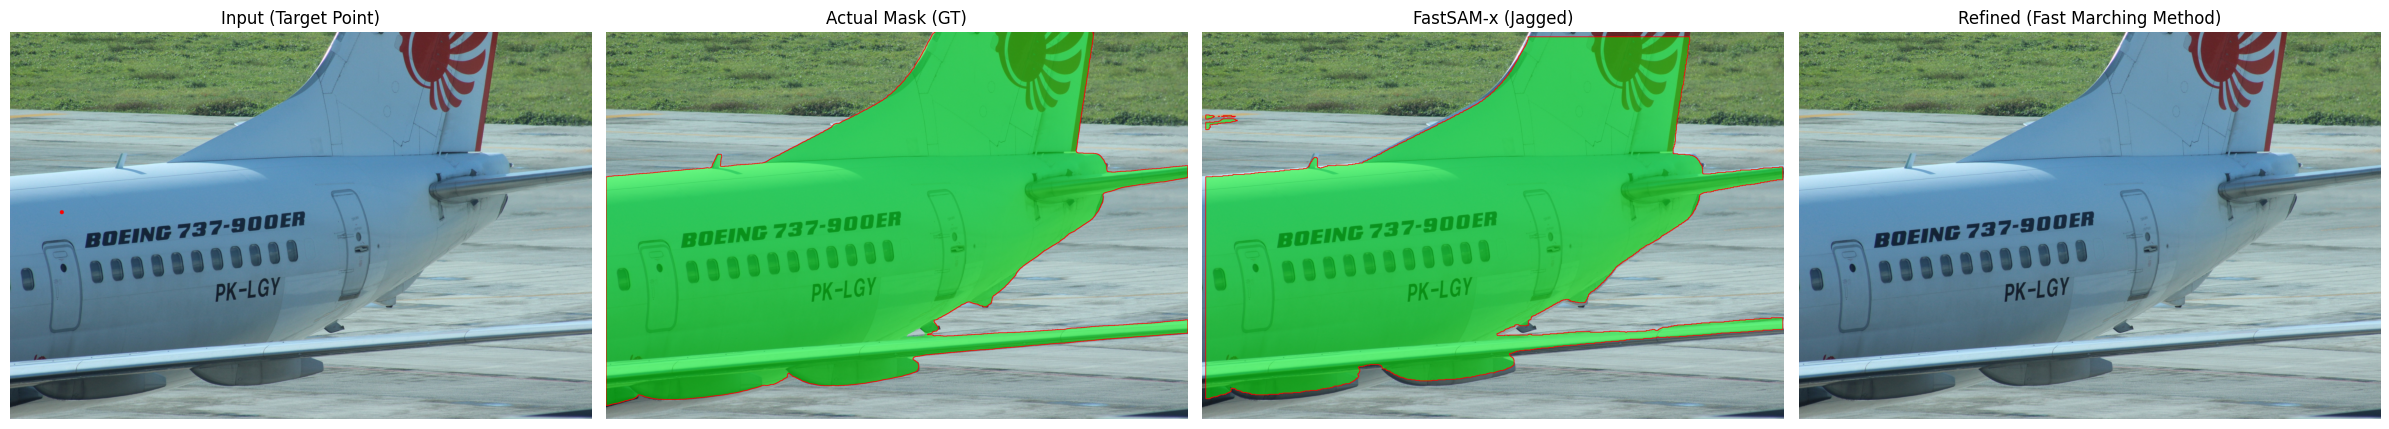

In [11]:
def create_overlay(img_base, mask, mask_color=(0, 255, 0), boundary_color=(255, 0, 0)):
    mask_bin = (mask > 0.5).astype(np.uint8)
    color_layer = np.zeros_like(img_base)
    color_layer[:] = mask_color
    alpha = mask[..., None] * 0.5 
    overlay = (img_base * (1 - alpha) + color_layer * alpha).astype(np.uint8)
    cnts, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, cnts, -1, boundary_color, 2)
    return overlay

print("6 & 7. Plotting Comparison...")
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Input
inp_plot = img_rgb.copy()
cv2.circle(inp_plot, (dummy_point[0], dummy_point[1]), 8, (255, 0, 0), -1)
axes[0].imshow(inp_plot); axes[0].set_title("Input (Target Point)"); axes[0].axis('off')

# GT
axes[1].imshow(create_overlay(img_rgb, actual_mask)); axes[1].set_title("Actual Mask (GT)"); axes[1].axis('off')

# FastSAM
axes[2].imshow(create_overlay(img_rgb, fastsam_mask)); axes[2].set_title("FastSAM-x (Jagged)"); axes[2].axis('off')

# Refined
axes[3].imshow(create_overlay(img_rgb, refined_mask)); axes[3].set_title(f"Refined ({method_name})"); axes[3].axis('off')

plt.tight_layout()
plt.savefig('refinement_test.png', dpi=300)
plt.show()